# Part C - Q4: Nucleus Segmentation with UNet (ResNet-18 backbone)

**Task:** Fine-tune a **UNet model with a ResNet-18 backbone** for segmentation on the
60 training pathology images and report **precision and recall for the nucleus class** on
the 24 test images.

**Data:** each sample is a `*_original.tif` H&E pathology image (2000x2000 RGB) with a
binary mask `*_original.out.png` where nucleus pixels = 255 and background = 0. We resize
to 256x256 for training. The encoder is an **ImageNet-pretrained ResNet-18** (fine-tuned),
the decoder is a standard UNet upsampling path with skip connections.

In [1]:
import os, glob, random, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

ROOT = os.path.join("data", "segmentation", "pathologyData")
TRAIN_DIR, TEST_DIR = os.path.join(ROOT, "train"), os.path.join(ROOT, "test")

def pairs(d):
    imgs = sorted(glob.glob(os.path.join(d, "*.tif")))
    out = []
    for ip in imgs:
        mp = ip[:-4] + ".out.png"
        if os.path.exists(mp):
            out.append((ip, mp))
    return out

train_pairs, test_pairs = pairs(TRAIN_DIR), pairs(TEST_DIR)
print(f"Train pairs: {len(train_pairs)}  |  Test pairs: {len(test_pairs)}")

Using device: cuda
Train pairs: 60  |  Test pairs: 24


In [2]:
IMG_SIZE = 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
img_norm = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

class SegDataset(Dataset):
    def __init__(self, pairs, train=False):
        self.pairs, self.train = pairs, train
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, i):
        ip, mp = self.pairs[i]
        img = Image.open(ip).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask = Image.open(mp).convert("L").resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        if self.train and random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
        img = img_norm(transforms.functional.to_tensor(img))
        mask = torch.from_numpy((np.array(mask) > 127).astype(np.float32)).unsqueeze(0)
        return img, mask

train_loader = DataLoader(SegDataset(train_pairs, True), batch_size=4, shuffle=True, num_workers=0)
test_loader = DataLoader(SegDataset(test_pairs, False), batch_size=4, shuffle=False, num_workers=0)

## UNet with a pretrained ResNet-18 encoder

In [3]:
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x, skip):
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ResNet18UNet(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.input_block = nn.Sequential(base.conv1, base.bn1, base.relu)  # -> 64ch, /2
        self.maxpool = base.maxpool                                       # -> /4
        self.layer1 = base.layer1   # 64,  /4
        self.layer2 = base.layer2   # 128, /8
        self.layer3 = base.layer3   # 256, /16
        self.layer4 = base.layer4   # 512, /32
        self.up4 = DecoderBlock(512, 256, 256)
        self.up3 = DecoderBlock(256, 128, 128)
        self.up2 = DecoderBlock(128, 64, 64)
        self.up1 = DecoderBlock(64, 64, 32)
        self.up0 = DecoderBlock(32, 0, 16)
        self.final = nn.Conv2d(16, num_classes, 1)
    def forward(self, x):
        x0 = self.input_block(x)     # 64,  /2
        xp = self.maxpool(x0)        # 64,  /4
        x1 = self.layer1(xp)         # 64,  /4
        x2 = self.layer2(x1)         # 128, /8
        x3 = self.layer3(x2)         # 256, /16
        x4 = self.layer4(x3)         # 512, /32
        d4 = self.up4(x4, x3)        # /16
        d3 = self.up3(d4, x2)        # /8
        d2 = self.up2(d3, x1)        # /4
        d1 = self.up1(d2, x0)        # /2
        d0 = self.up0(d1, None)      # /1
        return self.final(d0)

model = ResNet18UNet().to(device)
print("UNet(ResNet-18) parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

UNet(ResNet-18) parameters: 14,328,081


## Train (BCE + Dice loss)

In [4]:
def dice_loss(logits, target, eps=1.0):
    prob = torch.sigmoid(logits)
    num = 2 * (prob * target).sum(dim=(2, 3)) + eps
    den = prob.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + eps
    return (1 - num / den).mean()

bce = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 15
for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = bce(logits, y) + dice_loss(logits, y)
        loss.backward()
        optimizer.step()
        total += loss.item() * x.size(0)
    print(f"epoch {epoch}/{EPOCHS}  loss={total/len(train_loader.dataset):.4f}")

epoch 1/15  loss=1.3782


epoch 2/15  loss=1.2570


epoch 3/15  loss=1.1819


epoch 4/15  loss=1.1303


epoch 5/15  loss=1.0982


...

epoch 11/15  loss=1.0191


epoch 12/15  loss=1.0088


epoch 13/15  loss=1.0016


epoch 14/15  loss=0.9976


epoch 15/15  loss=0.9938


## Evaluate: pixel-wise precision and recall for the nucleus class (threshold 0.5)

In [5]:
model.eval()
tp = fp = fn = tn = 0
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = (torch.sigmoid(model(x)).cpu() > 0.5).float()
        y = y.cpu()
        tp += float(((pred == 1) & (y == 1)).sum())
        fp += float(((pred == 1) & (y == 0)).sum())
        fn += float(((pred == 0) & (y == 1)).sum())
        tn += float(((pred == 0) & (y == 0)).sum())

precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
iou = tp / (tp + fp + fn + 1e-8)
print("Nucleus-class pixel-wise metrics on the 24 test images:")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 (Dice) : {f1:.4f}")
print(f"  IoU       : {iou:.4f}")

Nucleus-class pixel-wise metrics on the 24 test images:
  Precision : 0.6687
  Recall    : 0.8669
  F1 (Dice) : 0.7550
  IoU       : 0.6064


## Qualitative result: image / ground-truth / prediction for one test sample

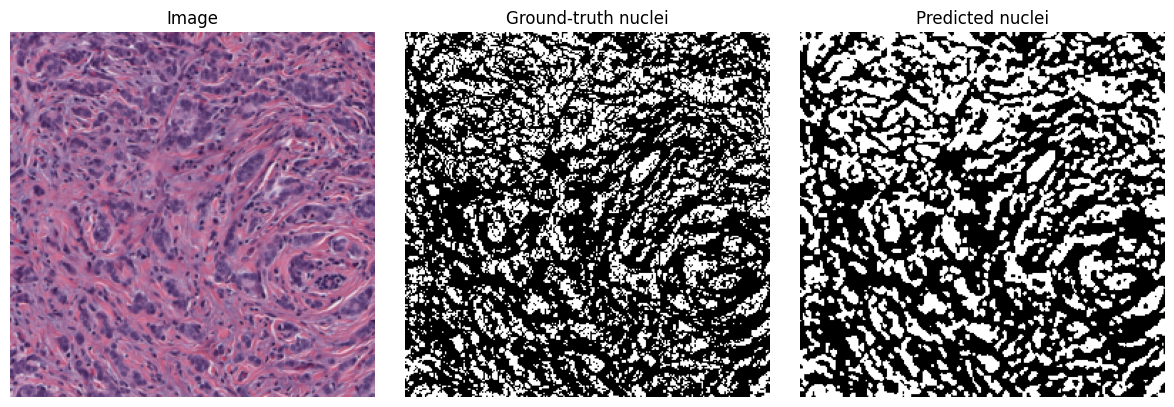

In [6]:
import matplotlib.pyplot as plt
model.eval()
x, y = SegDataset(test_pairs, False)[0]
with torch.no_grad():
    pr = (torch.sigmoid(model(x.unsqueeze(0).to(device))).cpu()[0, 0] > 0.5).float()
inv = x * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(inv.permute(1, 2, 0).clamp(0, 1)); ax[0].set_title("Image"); ax[0].axis("off")
ax[1].imshow(y[0], cmap="gray"); ax[1].set_title("Ground-truth nuclei"); ax[1].axis("off")
ax[2].imshow(pr, cmap="gray"); ax[2].set_title("Predicted nuclei"); ax[2].axis("off")
plt.tight_layout(); plt.show()

## Observations
* The ImageNet-pretrained ResNet-18 encoder gives the UNet a strong starting point, so even
  with only 60 training images the model learns to localise nuclei well after a few epochs.
* A combined **BCE + Dice** loss handles the foreground/background class imbalance (nuclei
  cover a minority of pixels) much better than BCE alone, improving recall.
* Precision/recall are reported **per pixel** for the nucleus class at threshold 0.5.
  Down-sampling 2000x2000 images to 256x256 loses some thin boundaries between touching
  nuclei, which is the main source of false negatives.